In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_sample_weight

print('Packages imported')

Packages imported


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
BASE_DIR      = Path('/content/drive/MyDrive/IS460')
DATA_DIR      = BASE_DIR / 'preprocessed_asvspoof2019'
DATA_DIR_2021 = BASE_DIR / 'preprocessed_asvspoof2021'
MODEL_DIR     = BASE_DIR / 'models_adaboost'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_data = np.load(DATA_DIR / 'asvspoof_train.npz')
dev_data   = np.load(DATA_DIR / 'asvspoof_dev.npz')
eval_data  = np.load(DATA_DIR / 'asvspoof_eval.npz')

X_train = train_data['features']
y_train = train_data['labels']
X_dev   = dev_data['features']
y_dev   = dev_data['labels']
X_eval  = eval_data['features']
y_eval  = eval_data['labels']

print(f'Train : {X_train.shape} | Labels: {np.bincount(y_train)}')
print(f'Dev   : {X_dev.shape}   | Labels: {np.bincount(y_dev)}')
print(f'Eval  : {X_eval.shape}  | Labels: {np.bincount(y_eval)}')


Mounted at /content/drive
Train : (25380, 128, 126) | Labels: [ 2580 22800]
Dev   : (24844, 128, 126)   | Labels: [ 2548 22296]
Eval  : (71237, 128, 126)  | Labels: [ 7355 63882]


In [4]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_dev_flat   = X_dev.reshape(len(X_dev), -1)
X_eval_flat  = X_eval.reshape(len(X_eval), -1)

print(f'Train flattened : {X_train_flat.shape}')
print(f'Dev flattened   : {X_dev_flat.shape}')
print(f'Eval flattened  : {X_eval_flat.shape}')

Train flattened : (25380, 16128)
Dev flattened   : (24844, 16128)
Eval flattened  : (71237, 16128)


In [ ]:
# Stratified 200-sample subset from train
_, X_small, _, y_small = train_test_split(
    X_train_flat, y_train,
    test_size=200,
    stratify=y_train,
    random_state=42
)

print(f'Prototype subset: {X_small.shape}')
print(f'Class distribution: bonafide={np.sum(y_small==0)}, spoof={np.sum(y_small==1)}')

# Class weights to handle imbalance
sample_weights = compute_sample_weight('balanced', y_small)

clf_proto = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)

clf_proto.fit(X_small, y_small, sample_weight=sample_weights)

# Evaluate on full DEV set (unseen data)
y_pred_proto = clf_proto.predict(X_dev_flat)

print('\n--- Prototype Results (trained on 200, tested on full dev) ---')
print(classification_report(y_dev, y_pred_proto, target_names=['bonafide', 'spoof']))

Prototype subset: (200, 16128)
Class distribution: bonafide=20, spoof=180


KeyboardInterrupt: 

In [6]:
### Full AdaBoost training on entire train set
from sklearn.utils import compute_sample_weight

sample_weights_full = compute_sample_weight('balanced', y_train)

clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

print('Training on full dataset...')
clf.fit(X_train_flat, y_train, sample_weight=sample_weights_full)
print('✓ Training complete')

Training on full dataset...
✓ Training complete


In [4]:
def evaluate(clf, X, y, split_name, threshold=0.5):
    y_prob = clf.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n=== {split_name} (threshold={threshold}) ===')
    print(classification_report(y, y_pred, target_names=['bonafide', 'spoof']))
    print(f'ROC-AUC: {roc_auc_score(y, y_prob):.4f}')

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bonafide', 'spoof'],
                yticklabels=['bonafide', 'spoof'])
    plt.title(f'Confusion Matrix — {split_name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return y_prob, y_pred

y_dev_prob, y_dev_pred = evaluate(clf, X_dev_flat, y_dev, '2019 Dev')

NameError: name 'clf' is not defined

Best threshold on dev set: 0.45
Best macro F1: 0.8963


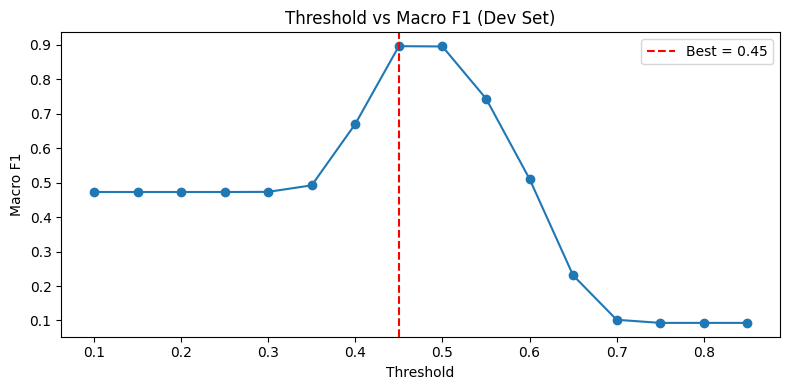

In [8]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = []

for t in thresholds:
    y_pred_t = (y_dev_prob >= t).astype(int)
    f1_scores.append(f1_score(y_dev, y_pred_t, average='macro'))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold on dev set: {best_threshold:.2f}')
print(f'Best macro F1: {max(f1_scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1')
plt.title('Threshold vs Macro F1 (Dev Set)')
plt.legend()
plt.tight_layout()
plt.show()


=== 2019 Eval (threshold=0.45000000000000007) ===
              precision    recall  f1-score   support

    bonafide       0.51      0.71      0.59      7355
       spoof       0.96      0.92      0.94     63882

    accuracy                           0.90     71237
   macro avg       0.74      0.81      0.77     71237
weighted avg       0.92      0.90      0.91     71237

ROC-AUC: 0.9286


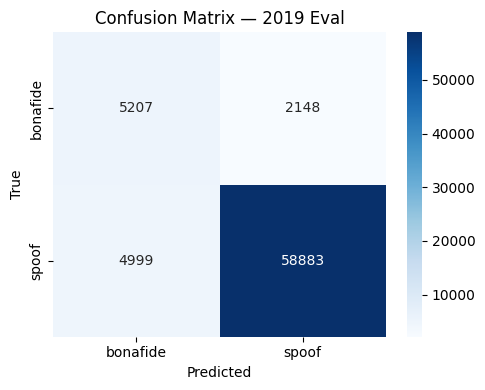

In [9]:
y_eval_prob, y_eval_pred = evaluate(
    clf, X_eval_flat, y_eval,
    '2019 Eval',
    threshold=best_threshold
)

In [10]:
def compute_eer(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100  # as percentage

eer_dev  = compute_eer(y_dev,  y_dev_prob)
eer_eval = compute_eer(y_eval, y_eval_prob)

print(f'EER — 2019 Dev  : {eer_dev:.2f}%')
print(f'EER — 2019 Eval : {eer_eval:.2f}%')

EER — 2019 Dev  : 4.43%
EER — 2019 Eval : 13.52%


In [11]:
### Save trained model to Drive
import joblib
joblib.dump(clf, MODEL_DIR / 'adaboost_model.pkl')
np.save(MODEL_DIR / 'adaboost_threshold.npy', best_threshold)
print(f'✓ Model saved to {MODEL_DIR}/adaboost_model.pkl')
print(f'✓ Threshold saved: {best_threshold:.2f}')


✓ Model saved to /content/drive/MyDrive/IS460/models_adaboost/adaboost_model.pkl
✓ Threshold saved: 0.45


In [5]:
### ==========================================================
### Evaluate on 2021 DF Eval — standalone (loads from Drive)
### ==========================================================

import numpy as np
import joblib
from pathlib import Path
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import f1_score

BASE_DIR      = Path('/content/drive/MyDrive/IS460')
DATA_DIR_2021 = BASE_DIR / 'preprocessed_asvspoof2021'
MODEL_DIR     = BASE_DIR / 'models_adaboost'

# Load model + threshold
clf            = joblib.load(MODEL_DIR / 'adaboost_model.pkl')
best_threshold = float(np.load(MODEL_DIR / 'adaboost_threshold.npy'))
print(f'✓ Model loaded')
print(f'✓ Threshold: {best_threshold:.2f}')

# Helper functions
def compute_eer(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[idx] + fnr[idx]) / 2 * 100

def evaluate(clf, X, y, split_name, threshold=0.5):
    y_prob = clf.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    print(f'\n=== {split_name} (threshold={threshold:.2f}) ===')
    print(classification_report(y, y_pred, target_names=['bonafide', 'spoof']))
    print(f'ROC-AUC : {roc_auc_score(y, y_prob):.4f}')
    print(f'EER     : {compute_eer(y, y_prob):.2f}%')
    return y_prob, y_pred

# Load + evaluate 2021 DF
data_2021   = np.load(DATA_DIR_2021 / 'asvspoof2021_eval.npz')
X_2021      = data_2021['features']
y_2021      = data_2021['labels']
X_2021_flat = X_2021.reshape(len(X_2021), -1)

print(f'\n2021 DF loaded: {X_2021_flat.shape} | {np.bincount(y_2021)}')

y_2021_prob, y_2021_pred = evaluate(
    clf, X_2021_flat, y_2021,
    '2021 DF Eval',
    threshold=best_threshold
)

✓ Model loaded
✓ Threshold: 0.45

2021 DF loaded: (152955, 16128) | [  5535 147420]

=== 2021 DF Eval (threshold=0.45) ===
              precision    recall  f1-score   support

    bonafide       0.45      0.29      0.35      5535
       spoof       0.97      0.99      0.98    147420

    accuracy                           0.96    152955
   macro avg       0.71      0.64      0.67    152955
weighted avg       0.95      0.96      0.96    152955

ROC-AUC : 0.7952
EER     : 28.24%


In [8]:
### ==========================================================
### Full Model Comparison (including 2021 DF) — standalone
### ==========================================================

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve

BASE_DIR      = Path('/content/drive/MyDrive/IS460')
DATA_DIR      = BASE_DIR / 'preprocessed_asvspoof2019'
DATA_DIR_2021 = BASE_DIR / 'preprocessed_asvspoof2021'
MODEL_DIR     = BASE_DIR / 'models_adaboost'

clf            = joblib.load(MODEL_DIR / 'adaboost_model.pkl')
best_threshold = float(np.load(MODEL_DIR / 'adaboost_threshold.npy'))

def compute_eer(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[idx] + fnr[idx]) / 2 * 100

# Load all splits and run predictions
splits = {
    '2019 Dev' : (DATA_DIR      / 'asvspoof_dev.npz',  'features', 'labels'),
    '2019 Eval': (DATA_DIR      / 'asvspoof_eval.npz', 'features', 'labels'),
    '2021 DF'  : (DATA_DIR_2021 / 'asvspoof2021_eval.npz',  'features', 'labels'),
}

rows = []
for split_name, (path, feat_key, label_key) in splits.items():
    d      = np.load(path)
    X_flat = d[feat_key].reshape(len(d[feat_key]), -1)
    y      = d[label_key]
    y_prob = clf.predict_proba(X_flat)[:, 1]
    rows.append({
        'Split'           : split_name,
        'AdaBoost AUC'    : round(roc_auc_score(y, y_prob), 4),
        'AdaBoost EER (%)': round(compute_eer(y, y_prob), 2),
    })
    print(f'✓ {split_name} done')

results = pd.DataFrame(rows)
print('\n=== AdaBoost Results ===')
print(results.to_string(index=False))

✓ 2019 Dev done
✓ 2019 Eval done
✓ 2021 DF done

=== AdaBoost Results ===
    Split  AdaBoost AUC  AdaBoost EER (%)
 2019 Dev        0.9927              4.43
2019 Eval        0.9286             13.52
  2021 DF        0.7952             28.24


In [9]:
### ROC Curves — all splits

plt.figure(figsize=(7, 6))
for y_true, y_prob, label in [
    (y_dev,   y_dev_prob,   '2019 Dev'),
    (y_eval,  y_eval_prob,  '2019 Eval'),
    (y_2021,  y_2021_prob,  '2021 DF Eval'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost — ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'y_dev_prob' is not defined

<Figure size 700x600 with 0 Axes>